# 🌙 Reetiquetado por Hipnograma — CAP Sleep Database (enfoque corregido)

**Notebook 0 del pipeline reorientado a clasificación de fases de sueño.**

### Por qué este notebook

El proyecto original etiquetaba cada ventana con el **diagnóstico del
paciente** (insomnio, RBD, SDB…), lo que convertía la tarea en
"reconocer al paciente" en vez de "reconocer la fase de sueño". Este
notebook corrige el error de raíz: extrae las **etiquetas reales de fase**
desde el hipnograma anotado por el técnico y las sincroniza con las
señales.

### Qué produce

Una tabla `(epoch_idx, patient, onset_s, duration, stage)` por paciente,
donde cada fila es una época de 30 s con su fase R&K verdadera. Esta tabla
es la base para que el notebook de extracción de características asigne a
cada ventana su etiqueta correcta.

### Decisiones de diseño (acordadas)

| Decisión | Elección |
|----------|----------|
| Tamaño de ventana | **30 s** (1:1 con las épocas del hipnograma) |
| Esquema de clases | **6 clases R&K**: W, S1, S2, S3, S4, REM |
| Épocas MT / UNSCORED | **Descartar** (no son fases R&K) |
| Sincronización | Por **timestamp real** de cada época (no por índice) |

## 1. Formato de los archivos de anotación

Los archivos `.txt` de la CAP Sleep Database usados aquí están en formato
**RemLogic Event Export**. Su estructura:

```
RemLogic Event Export
Patient:    SDB 4
Recording Date:  01/01/2007
...
Events Included:
  MCAP-A1, MCAP-A2, MCAP-A3        ← eventos CAP (microestructura)
  SLEEP-REM, SLEEP-S0...S4         ← épocas de fase (macroestructura)
  SLEEP-UNSCORED
...
Sleep Stage   Position   Time [hh:mm:ss]   Event   Duration[s]   Location
W    Unknown Position    22:34:35    SLEEP-S0    30    ROC-LOC
S1   Unknown Position    22:37:05    SLEEP-S1    30    ROC-LOC
S1   Unknown Position    22:41:37    MCAP-A3     17    EEG-F4-C4   ← evento CAP, NO época
...
```

### Observaciones críticas (verificadas sobre los datos reales)

1. **Dos codificaciones de fase coexisten.** La columna `Sleep Stage`
   (W, S1–S4, R, MT) y la columna `Event` (SLEEP-S0…S4, SLEEP-REM,
   MCAP-*). Para el hipnograma usamos la columna **`Event`** filtrando las
   que empiezan por `SLEEP-`, porque las filas MCAP también llevan un valor
   en `Sleep Stage` que contaminaría el conteo.

2. **`SLEEP-S0` = Wake.** En la nomenclatura RemLogic, S0 es vigilia (W).

3. **Filas MCAP son eventos CAP, no épocas.** Tienen duración variable
   (7–29 s) y se descartan para el hipnograma (se usarían en una tarea
   distinta de detección de CAP).

4. **Hay épocas faltantes.** El hipnograma NO es perfectamente contiguo:
   existen saltos de 60 s donde el técnico no puntuó una época de 30 s.
   Por eso **cada época debe alinearse por su timestamp real**, nunca
   asumiendo que la época *n* empieza en *n*×30 s.

5. **Cruce de medianoche.** Las grabaciones empiezan ~22:00 y terminan
   ~07:00, así que la hora de reloj "baja" al pasar medianoche; hay que
   sumar 24 h al detectar el salto.

## 2. Importaciones y configuración

In [1]:
import os
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (14, 4),
    'axes.titlesize': 13, 'axes.labelsize': 11, 'font.size': 10,
})
sns.set_style('whitegrid')

# ── Rutas ──
# Ajusta UPLOADS_DIR a donde tengas los .txt de anotación
UPLOADS_DIR    = Path('../data/cap-sleep-database')      # archivos .txt
ANNOTATIONS_DIR = UPLOADS_DIR                          # idem
OUTPUT_DIR     = Path.cwd() / '../data/hypnograms'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Esquema de clases: 6 fases R&K ──
EVENT_TO_STAGE = {
    'SLEEP-S0':  'W',     # S0 = vigilia
    'SLEEP-S1':  'S1',
    'SLEEP-S2':  'S2',
    'SLEEP-S3':  'S3',
    'SLEEP-S4':  'S4',
    'SLEEP-REM': 'REM',
}
# MT, UNSCORED y cualquier otro Event (MCAP-*) NO están en el mapeo
# y por tanto se descartan.

CLASES_RK = ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
EPOCH_SECONDS = 30

print('Clases objetivo (R&K):', CLASES_RK)
print('Mapeo Event -> fase  :')
for k, v in EVENT_TO_STAGE.items():
    print(f'    {k:<12} -> {v}')
print('Épocas MT / UNSCORED : DESCARTADAS')

Clases objetivo (R&K): ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
Mapeo Event -> fase  :
    SLEEP-S0     -> W
    SLEEP-S1     -> S1
    SLEEP-S2     -> S2
    SLEEP-S3     -> S3
    SLEEP-S4     -> S4
    SLEEP-REM    -> REM
Épocas MT / UNSCORED : DESCARTADAS


## 3. Parser del hipnograma

La función `parsear_hipnograma` implementa todas las observaciones de la
Sección 1. Está diseñada de forma defensiva para tolerar variaciones de
formato entre pacientes:

- Localiza dinámicamente la fila de encabezado de la tabla (no asume número
  fijo de líneas de cabecera).
- Filtra solo épocas `SLEEP-*`.
- Mapea a las 6 clases R&K; lo no mapeado (MT, UNSCORED) se descarta.
- Convierte la hora de reloj a segundos absolutos manejando el cruce de
  medianoche.
- Calcula `onset_s` como el tiempo **real** de inicio de cada época
  relativo a la primera, preservando los huecos de épocas faltantes.

In [2]:
def parsear_hipnograma(ruta, event_to_stage=EVENT_TO_STAGE):
    '''
    Lee un archivo de anotación RemLogic y devuelve el hipnograma.

    Returns
    -------
    pd.DataFrame con columnas:
        epoch_idx : índice secuencial de época válida
        onset_s   : inicio de la época en segundos desde la 1ª época
        duration  : duración (siempre 30 para épocas de fase)
        stage     : fase R&K {W, S1, S2, S3, S4, REM}
        time_str  : hora de reloj original (hh:mm:ss)
    info : dict con metadatos del parseo (descartadas, gaps, etc.)
    '''
    with open(ruta, 'r', encoding='utf-8', errors='replace') as f:
        lineas = [ln.rstrip('\r\n') for ln in f]

    # 1) Localizar encabezado de la tabla de eventos
    idx_header = None
    for i, ln in enumerate(lineas):
        if ln.startswith('Sleep Stage') and 'Time' in ln and 'Event' in ln:
            idx_header = i
            break
    if idx_header is None:
        raise ValueError(f'No se encontró la tabla de eventos en {ruta.name}')

    header = lineas[idx_header].split('\t')

    # 2) Parsear filas de datos
    filas = []
    for ln in lineas[idx_header + 1:]:
        if not ln.strip():
            continue
        campos = ln.split('\t')
        if len(campos) < 5:
            continue
        filas.append(campos[:len(header)])

    df = pd.DataFrame(filas, columns=header).rename(columns={
        'Sleep Stage': 'sleep_stage_raw',
        'Time [hh:mm:ss]': 'time_str',
        'Event': 'event',
        'Duration[s]': 'duration',
    })

    n_total_filas = len(df)

    # 3) Filtrar SOLO épocas de fase (Event empieza con SLEEP-)
    df = df[df['event'].str.startswith('SLEEP-')].copy()
    n_sleep = len(df)
    df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

    # 4) Mapear a las 6 clases R&K; descartar lo no mapeado (S0->W incluido)
    df['stage'] = df['event'].map(event_to_stage)
    n_antes_map = len(df)
    df = df.dropna(subset=['stage']).copy()
    n_descartadas = n_antes_map - len(df)

    # 5) Convertir hora a segundos, manejando cruce de medianoche
    def a_segundos(hhmmss):
        h, m, s = map(int, hhmmss.split(':'))
        return h * 3600 + m * 60 + s

    df['sec_reloj'] = df['time_str'].apply(a_segundos)
    secs = df['sec_reloj'].tolist()
    ajustados, offset, prev = [], 0, None
    for s in secs:
        if prev is not None and s < prev - 1:   # la hora bajó => medianoche
            offset += 24 * 3600
        ajustados.append(s + offset)
        prev = s
    df['sec_abs'] = ajustados
    df['onset_s'] = df['sec_abs'] - df['sec_abs'].iloc[0]

    df = df.reset_index(drop=True)
    df['epoch_idx'] = df.index

    # 6) Diagnóstico de continuidad temporal
    difs = df['onset_s'].diff().dropna()
    n_gaps = int((difs != EPOCH_SECONDS).sum())
    epocas_faltantes = int(((difs - EPOCH_SECONDS) / EPOCH_SECONDS).clip(lower=0).sum())

    info = {
        'archivo': ruta.name,
        'filas_totales': n_total_filas,
        'filas_sleep': n_sleep,
        'epocas_validas': len(df),
        'descartadas_mt_unscored': n_descartadas,
        'gaps_no_30s': n_gaps,
        'epocas_faltantes_estimadas': epocas_faltantes,
        'duracion_h': round((df['onset_s'].iloc[-1] + EPOCH_SECONDS) / 3600, 2),
    }

    cols = ['epoch_idx', 'onset_s', 'duration', 'stage', 'event', 'time_str']
    return df[cols], info

## 4. Aplicación a los archivos disponibles

Procesamos todos los `.txt` encontrados en el directorio de anotaciones.

In [3]:
# Descubrir archivos de anotación disponibles
archivos_txt = sorted(ANNOTATIONS_DIR.glob('*.txt'))
print(f'Archivos de anotación encontrados: {len(archivos_txt)}')
for a in archivos_txt:
    print(f'  - {a.name}')

if not archivos_txt:
    raise FileNotFoundError(
        f'No se encontraron .txt en {ANNOTATIONS_DIR}. '
        'Ajusta ANNOTATIONS_DIR a la carpeta con tus anotaciones.'
    )

Archivos de anotación encontrados: 109
  - brux1.txt
  - brux2.txt
  - ins1.txt
  - ins2.txt
  - ins3.txt
  - ins4.txt
  - ins5.txt
  - ins6.txt
  - ins7.txt
  - ins8.txt
  - ins9.txt
  - n1.txt
  - n10.txt
  - n11.txt
  - n12.txt
  - n13.txt
  - n14.txt
  - n15.txt
  - n16.txt
  - n2.txt
  - n3.txt
  - n4.txt
  - n5.txt
  - n6.txt
  - n7.txt
  - n8.txt
  - n9.txt
  - narco1.txt
  - narco2.txt
  - narco3.txt
  - narco4.txt
  - narco5.txt
  - nfle1.txt
  - nfle10.txt
  - nfle11.txt
  - nfle12.txt
  - nfle13.txt
  - nfle14.txt
  - nfle15.txt
  - nfle16.txt
  - nfle17.txt
  - nfle18.txt
  - nfle19.txt
  - nfle2.txt
  - nfle20.txt
  - nfle21.txt
  - nfle22.txt
  - nfle23.txt
  - nfle24.txt
  - nfle25.txt
  - nfle26.txt
  - nfle27.txt
  - nfle28.txt
  - nfle29.txt
  - nfle3.txt
  - nfle30.txt
  - nfle31.txt
  - nfle32.txt
  - nfle33.txt
  - nfle34.txt
  - nfle35.txt
  - nfle36.txt
  - nfle37.txt
  - nfle38.txt
  - nfle39.txt
  - nfle4.txt
  - nfle40.txt
  - nfle5.txt
  - nfle6.txt
  - nfle7

In [4]:
# Parsear todos y consolidar
hipnogramas = {}
infos = []
for ruta in archivos_txt:
    # El nombre del paciente es el nombre del archivo sin extensión
    patient = ruta.stem
    try:
        hip, info = parsear_hipnograma(ruta)
        hip.insert(1, 'patient', patient)
        hipnogramas[patient] = hip
        infos.append(info)
    except Exception as e:
        print(f'  ⚠️  Error procesando {ruta.name}: {e}')

info_df = pd.DataFrame(infos)
print('Resumen del parseo:')
print(info_df.to_string(index=False))

  ⚠️  Error procesando brux1.txt: invalid literal for int() with base 10: '22.18.17'
  ⚠️  Error procesando n16.txt: 'duration'
  ⚠️  Error procesando narco2.txt: invalid literal for int() with base 10: '21.50.53'
  ⚠️  Error procesando SHA256SUMS.txt: No se encontró la tabla de eventos en SHA256SUMS.txt
Resumen del parseo:
   archivo  filas_totales  filas_sleep  epocas_validas  descartadas_mt_unscored  gaps_no_30s  epocas_faltantes_estimadas  duracion_h
 brux2.txt           1511         1029            1029                        0            7                           8        8.64
  ins1.txt           1225          906             906                        0            9                          10        7.63
  ins2.txt           1929         1675            1675                        0            0                           0       13.96
  ins3.txt           1164          856             856                        0           11                          11        7.22
  ins4.tx

## 5. Verificación de calidad

### 5.1 Épocas faltantes

Los **gaps de 60 s** indican épocas que el técnico no puntuó. Es un
fenómeno real y esperado: el hipnograma no siempre es contiguo. La clave
metodológica es que **alineamos por `onset_s` real**, así que las épocas
faltantes simplemente no generan ventana — no desplazan al resto.

In [5]:
for patient, hip in hipnogramas.items():
    difs = hip['onset_s'].diff().dropna()
    gaps = difs[difs != EPOCH_SECONDS]
    print(f'\n{patient}: {len(hip)} épocas válidas, '
          f'{len(gaps)} gaps (épocas faltantes ~{int(((gaps-30)/30).sum())})')
    if len(gaps):
        print(f'  Tamaños de gap: {sorted(gaps.unique().astype(int))} s')


brux2: 1029 épocas válidas, 7 gaps (épocas faltantes ~8)
  Tamaños de gap: [np.int64(60), np.int64(90)] s

ins1: 906 épocas válidas, 9 gaps (épocas faltantes ~10)
  Tamaños de gap: [np.int64(60), np.int64(90)] s

ins2: 1675 épocas válidas, 0 gaps (épocas faltantes ~0)

ins3: 856 épocas válidas, 11 gaps (épocas faltantes ~11)
  Tamaños de gap: [np.int64(60)] s

ins4: 718 épocas válidas, 15 gaps (épocas faltantes ~15)
  Tamaños de gap: [np.int64(60)] s

ins5: 1720 épocas válidas, 0 gaps (épocas faltantes ~0)

ins6: 1057 épocas válidas, 0 gaps (épocas faltantes ~0)

ins7: 1483 épocas válidas, 0 gaps (épocas faltantes ~0)

ins8: 833 épocas válidas, 7 gaps (épocas faltantes ~7)
  Tamaños de gap: [np.int64(60)] s

ins9: 1050 épocas válidas, 0 gaps (épocas faltantes ~0)

n1: 1140 épocas válidas, 7 gaps (épocas faltantes ~7)
  Tamaños de gap: [np.int64(60)] s

n10: 852 épocas válidas, 8 gaps (épocas faltantes ~8)
  Tamaños de gap: [np.int64(60)] s

n11: 1051 épocas válidas, 2 gaps (épocas fal

### 5.2 Distribución de fases por paciente

El sueño humano normal está **fuertemente desbalanceado**: S2 domina
(~45–50 % de la noche), mientras que S1 y a veces REM son minoritarias.
Este desbalance es fisiológico y debe tenerse en cuenta en el modelado.

In [6]:
# Tabla de distribución de fases
dist = pd.DataFrame({
    p: hip['stage'].value_counts().reindex(CLASES_RK).fillna(0).astype(int)
    for p, hip in hipnogramas.items()
}).T
dist['TOTAL'] = dist.sum(axis=1)
print('Distribución de épocas por fase y paciente:')
print(dist.to_string())

print('\nPorcentajes por paciente:')
dist_pct = dist[CLASES_RK].div(dist['TOTAL'], axis=0) * 100
print(dist_pct.round(1).to_string())

Distribución de épocas por fase y paciente:
stage     W   S1   S2   S3   S4  REM  TOTAL
brux2   127  108  298  123  166  207   1029
ins1    121   33  489  130    0  133    906
ins2    837    5  455  145    0  233   1675
ins3    229  132  190   65  107  133    856
ins4     63    6  341   61   97  150    718
ins5    918    5  430   96   98  173   1720
ins6    494   62  227   64  122   88   1057
ins7    610   19  509   64   61  220   1483
ins8    231   73  268  184    0   77    833
ins9    654   53  215   51   37   40   1050
n1       39   33  508  135  186  239   1140
n10      66    2  261   45  263  215    852
n11      56    6  266   61  282  380   1051
n12      31    5  423   73  155  297    984
n13     194   17  421   40   99  181    952
n14     157   12  354  146  131  165    965
n15      39   17  504  144   74  198    976
n2      143  141  367   83  114  151    999
n3      136   49  347  112  167  188    999
n4      223   18  401   63   76  198    979
n5       10   49  413  134  169 

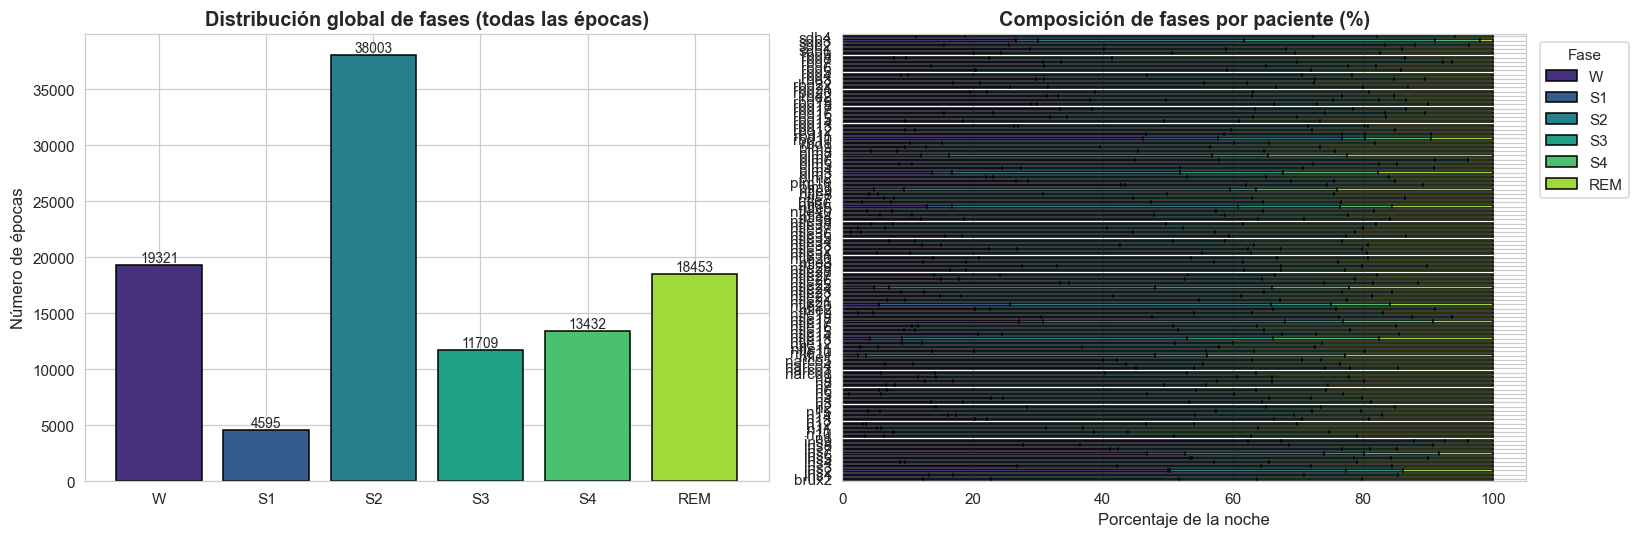

Figura guardada en D:\Repos\RAHBFDP-2026\notebooks\..\data\hypnograms\distribucion_fases.png


In [7]:
# Visualización: distribución de clases agregada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

total_por_clase = dist[CLASES_RK].sum()
colores = sns.color_palette('viridis', len(CLASES_RK))
axes[0].bar(CLASES_RK, total_por_clase.values, color=colores, edgecolor='black')
axes[0].set_title('Distribución global de fases (todas las épocas)',
                  fontweight='bold')
axes[0].set_ylabel('Número de épocas')
for i, v in enumerate(total_por_clase.values):
    axes[0].text(i, v, str(int(v)), ha='center', va='bottom', fontsize=9)

# Distribución relativa por paciente (barras apiladas)
dist_pct[CLASES_RK].plot(kind='barh', stacked=True, ax=axes[1],
                          color=colores, edgecolor='black')
axes[1].set_title('Composición de fases por paciente (%)', fontweight='bold')
axes[1].set_xlabel('Porcentaje de la noche')
axes[1].legend(title='Fase', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_fases.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en {OUTPUT_DIR / "distribucion_fases.png"}')

## 6. Visualización del hipnograma

El **hipnograma** es la representación clásica de la arquitectura del
sueño: fase en el eje Y, tiempo en el eje X. Permite ver la alternancia
NREM↔REM en ciclos de ~90 min y la profundización progresiva hacia S3/S4
en la primera mitad de la noche.

Convención de orden vertical (de arriba abajo): W, REM, S1, S2, S3, S4
— las fases más profundas abajo, como en la práctica clínica.

In [8]:
# Orden vertical clínico del hipnograma
ORDEN_HIPNO = ['W', 'REM', 'S1', 'S2', 'S3', 'S4']
stage_to_y = {s: i for i, s in enumerate(ORDEN_HIPNO)}

fig, axes = plt.subplots(len(hipnogramas), 1,
                         figsize=(14, 3.2 * len(hipnogramas)),
                         squeeze=False)
for ax, (patient, hip) in zip(axes[:, 0], hipnogramas.items()):
    horas = hip['onset_s'] / 3600
    y = hip['stage'].map(stage_to_y)
    ax.step(horas, y, where='post', linewidth=0.9, color='#2C3E50')
    ax.set_yticks(range(len(ORDEN_HIPNO)))
    ax.set_yticklabels(ORDEN_HIPNO)
    ax.invert_yaxis()
    ax.set_xlabel('Tiempo (horas desde inicio del registro)')
    ax.set_title(f'Hipnograma — {patient}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hipnogramas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en {OUTPUT_DIR / "hipnogramas.png"}')

Figura guardada en D:\Repos\RAHBFDP-2026\notebooks\..\data\hypnograms\hipnogramas.png


## 7. Sincronización con las señales EEG (EDF)

### El problema de alineación

El hipnograma da la hora de **reloj** de cada época (p. ej. 22:34:35). El
archivo `.edf` tiene su propia hora de inicio de grabación en la cabecera
(`meas_date`). Para extraer el tramo de señal correcto de cada época hay
que calcular el **offset** entre ambos:

$$\text{offset}_\text{época} = (\text{hora\_reloj}_\text{época} - \text{hora\_inicio}_\text{EDF})$$

y luego el tramo de señal de esa época es
`raw[:, offset*fs : (offset + 30)*fs]`.

### Función de sincronización

> **Nota:** esta celda requiere los archivos `.edf` correspondientes. Si no
> están disponibles en este entorno, la función queda lista y documentada
> para ejecutarse donde tengas los EDF. Ajusta `EDF_DIR` a tu carpeta.

In [9]:
EDF_DIR = UPLOADS_DIR  # ajusta a la carpeta con tus .edf

def sincronizar_con_edf(patient, hip, edf_dir=EDF_DIR, verbose=True):
    '''
    Cruza el hipnograma de un paciente con su señal EDF y devuelve, por cada
    época válida, el índice de muestra inicial dentro del EDF.

    Requiere MNE. Lee la hora de inicio del EDF (meas_date) y la usa como
    referencia temporal absoluta.

    Returns
    -------
    pd.DataFrame con el hipnograma + columnas:
        edf_start_sample : muestra inicial de la época en el EDF
        edf_start_sec    : segundo inicial de la época en el EDF
    o None si el EDF no existe.
    '''
    import mne

    edf_path = Path(edf_dir) / f'{patient}.edf'
    if not edf_path.exists():
        if verbose:
            print(f'  ⚠️  {edf_path.name} no encontrado; se omite sincronización.')
        return None

    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='ERROR')
    fs = raw.info['sfreq']
    meas_date = raw.info['meas_date']  # datetime con tz UTC

    # Hora de inicio del EDF en segundos desde medianoche
    edf_start_clock = (meas_date.hour * 3600 + meas_date.minute * 60 +
                       meas_date.second)

    # Hora de la primera época del hipnograma (segundos desde medianoche)
    h, m, s = map(int, hip['time_str'].iloc[0].split(':'))
    hip_start_clock = h * 3600 + m * 60 + s

    # Offset entre inicio del hipnograma y inicio del EDF (maneja medianoche)
    offset_inicial = hip_start_clock - edf_start_clock
    if offset_inicial < -12 * 3600:
        offset_inicial += 24 * 3600
    elif offset_inicial > 12 * 3600:
        offset_inicial -= 24 * 3600

    hip = hip.copy()
    hip['edf_start_sec'] = offset_inicial + hip['onset_s']
    hip['edf_start_sample'] = (hip['edf_start_sec'] * fs).round().astype(int)

    # Descartar épocas que caigan fuera del rango del EDF
    n_muestras = raw.n_times
    fin_muestra = hip['edf_start_sample'] + int(EPOCH_SECONDS * fs)
    validas = (hip['edf_start_sample'] >= 0) & (fin_muestra <= n_muestras)
    n_fuera = (~validas).sum()
    hip = hip[validas].reset_index(drop=True)

    if verbose:
        print(f'  {patient}: fs={fs:.0f} Hz, EDF inicia {meas_date.time()}, '
              f'hipno inicia {hip["time_str"].iloc[0]}, '
              f'offset={offset_inicial}s, épocas fuera de rango={n_fuera}')
    return hip


# Intentar sincronizar (si hay EDF disponibles)
hipnogramas_sync = {}
for patient, hip in hipnogramas.items():
    try:
        sync = sincronizar_con_edf(patient, hip)
        if sync is not None:
            hipnogramas_sync[patient] = sync
    except ImportError:
        print('  ⚠️  MNE no está instalado; instala con: pip install mne')
        break
    except Exception as e:
        print(f'  ⚠️  Error sincronizando {patient}: {e}')

if hipnogramas_sync:
    print(f'\n✅ Sincronizados {len(hipnogramas_sync)} pacientes con sus EDF')
else:
    print('\nℹ️  Sin EDF disponibles: el hipnograma queda listo igualmente. '
          'La sincronización se ejecutará cuando tengas los .edf.')

  brux2: fs=256 Hz, EDF inicia 22:05:16, hipno inicia 22:08:16, offset=180s, épocas fuera de rango=0
  ins1: fs=256 Hz, EDF inicia 18:05:58, hipno inicia 22:30:28, offset=15870s, épocas fuera de rango=0
  ins2: fs=512 Hz, EDF inicia 18:25:37, hipno inicia 18:25:38, offset=1s, épocas fuera de rango=1
  ins3: fs=256 Hz, EDF inicia 20:39:02, hipno inicia 22:00:42, offset=4900s, épocas fuera de rango=1
  ins4: fs=512 Hz, EDF inicia 18:07:34, hipno inicia 21:34:04, offset=12390s, épocas fuera de rango=0
  ins5: fs=512 Hz, EDF inicia 17:58:48, hipno inicia 17:58:48, offset=0s, épocas fuera de rango=0
  ins6: fs=512 Hz, EDF inicia 18:46:57, hipno inicia 22:37:17, offset=13820s, épocas fuera de rango=0
  ins7: fs=512 Hz, EDF inicia 19:58:14, hipno inicia 19:58:14, offset=0s, épocas fuera de rango=0
  ins8: fs=512 Hz, EDF inicia 22:16:34, hipno inicia 22:43:04, offset=1590s, épocas fuera de rango=0
  ins9: fs=512 Hz, EDF inicia 22:28:44, hipno inicia 22:28:44, offset=0s, épocas fuera de rango=0

## 8. Exportación

Guardamos el hipnograma consolidado de todos los pacientes. Este archivo es
la entrada del notebook de extracción de características reorientado: cada
ventana de 30 s tomará su etiqueta de la época correspondiente vía
`onset_s` / `edf_start_sample`.

In [10]:
# Consolidar todos los hipnogramas en una sola tabla
tabla_final = pd.concat(
    [hipnogramas_sync.get(p, hip) for p, hip in hipnogramas.items()],
    ignore_index=True,
)

# Reordenar columnas
cols_orden = ['patient', 'epoch_idx', 'onset_s', 'duration', 'stage']
if 'edf_start_sample' in tabla_final.columns:
    cols_orden += ['edf_start_sample', 'edf_start_sec']
cols_orden += ['event', 'time_str']
tabla_final = tabla_final[[c for c in cols_orden if c in tabla_final.columns]]

ruta_out = OUTPUT_DIR / 'hipnogramas_consolidado.csv'
tabla_final.to_csv(ruta_out, index=False)

# Guardar también por paciente
for patient, hip in hipnogramas.items():
    h = hipnogramas_sync.get(patient, hip)
    h.to_csv(OUTPUT_DIR / f'{patient}_hipnograma.csv', index=False)

print(f'✅ Tabla consolidada: {tabla_final.shape}')
print(f'   Guardada en {ruta_out}')
print(f'\nVista previa:')
print(tabla_final.head(8).to_string(index=False))

print(f'\nArchivos generados en {OUTPUT_DIR}:')
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f'  {f.name}')

✅ Tabla consolidada: (105382, 9)
   Guardada en D:\Repos\RAHBFDP-2026\notebooks\..\data\hypnograms\hipnogramas_consolidado.csv

Vista previa:
patient  epoch_idx  onset_s  duration stage  edf_start_sample  edf_start_sec    event time_str
  brux2          0        0        30     W             46080            180 SLEEP-S0 22:08:16
  brux2          1       30        30     W             53760            210 SLEEP-S0 22:08:46
  brux2          2       60        30     W             61440            240 SLEEP-S0 22:09:16
  brux2          3       90        30     W             69120            270 SLEEP-S0 22:09:46
  brux2          4      120        30     W             76800            300 SLEEP-S0 22:10:16
  brux2          5      150        30     W             84480            330 SLEEP-S0 22:10:46
  brux2          6      180        30     W             92160            360 SLEEP-S0 22:11:16
  brux2          7      210        30     W             99840            390 SLEEP-S0 22:11:46

Ar

## 9. Resumen y siguiente paso

### Lo que produjo este notebook

- Un **parser robusto** del formato RemLogic, verificado contra archivos
  reales, que maneja: filtrado SLEEP-*, descarte de MT/UNSCORED/MCAP,
  cruce de medianoche y épocas faltantes.
- Un **hipnograma por paciente** con la fase R&K verdadera y el `onset_s`
  real de cada época.
- La **lógica de sincronización con EDF** vía `meas_date`, lista para
  ejecutarse con los archivos de señal.
- La tabla consolidada `hipnogramas_consolidado.csv`.

### Diferencia clave con el proyecto original

| Antes (incorrecto) | Ahora (correcto) |
|--------------------|------------------|
| Etiqueta = diagnóstico del paciente | Etiqueta = fase de sueño real de la época |
| Misma etiqueta para todas las ventanas | Etiqueta cambia época a época |
| "Reconocer al paciente" | "Reconocer la fase de sueño" |

### Siguiente notebook

El **notebook de extracción de características reorientado** tomará
`hipnogramas_consolidado.csv` y, para cada época de 30 s:

1. Extraerá el tramo de señal `[edf_start_sample : +30s]` del EDF.
2. Calculará las características (reusando las funciones del pipeline
   original, adaptadas a ventanas de 30 s = 7680 muestras a 256 Hz).
3. Asignará la etiqueta `stage` de la época.

El resultado será el dataset `(características, stage)` correctamente
etiquetado para entrenar los clasificadores de fase con **validación por
paciente**.